In [1]:
#| hide
# BASED ON
  # Kalman filtering and smoothing-1_ANNO^V5.ipynb
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# split into 3 pars
# clean
# v6 starts ------------------------------------------------
# migrate to cursor & github
# change s --> x (for state)
# tildes --> * for true quantities
# switch roles of A & B back again to eng convention, but B --> C
# remove all underscores indicating globals
# add underscores for bold symbols which have spatial structure

# TODO
# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [2]:
versioninfo() ##. Julia version

Julia Version 1.10.0
Commit 3120989f39b (2023-12-25 18:01 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
  Threads: 1 on 12 virtual cores


In [3]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
using RxInfer, BenchmarkTools, Random, LinearAlgebra, Plots, LaTeXStrings, Distributions, StableRNGs

  Activating project at `/workspaces/GaussianMvStateInference`
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API /home/vscode/.julia/juliaup/julia-1.10.0+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/API.jl:1800


In [4]:
Pkg.status()

Status `/workspaces/GaussianMvStateInference/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [31c24e10] Distributions v0.25.131
  [b964fa9f] LaTeXStrings v1.4.1
  [91a5bcdd] Plots v1.41.6
⌃ [86711068] RxInfer v3.7.1
  [860ef19b] StableRNGs v1.0.4
Info Packages marked with ⌃ have new versions available and may be upgradable.
Warning The project dependencies or compat requirements have changed since the manifest was last resolved. It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.


# Kalman filtering and smoothing

In the following set of examples the goal is to estimate hidden <u>states</u> of a Dynamical process where all hidden states are Gaussians.

We start our journey with a simple 

- (1) multivariate Linear Gaussian State Space Model (LGSSM), which can be solved analytically. We then solve an 
- (2) identification problem which does not have an analytical solution. Utimately, we show how **RxInfer.jl** can 
- (3) deal with missing observations.

# 1 Gaussian Linear Dynamical System

LGSSM can be described with the following equations:

$$\begin{aligned}
 p(\mathbf{x}_t|\mathbf{x}_{t - 1}) & = \mathcal{N}(\mathbf{x}_t|\mathbf{A} \mathbf{x}_{t - 1}, \mathbf{Q}),\\
 p(\mathbf{y}_t|\mathbf{x}_t) & = \mathcal{N}(\mathbf{y}_t|\mathbf{C} \mathbf{x}_t, \mathbf{R}),
\end{aligned}$$

where $\mathbf{x}_t$ are hidden states, $\mathbf{y}_t$ are noisy observations, $\mathbf{A}$, $\mathbf{C}$ are state transition and observation matrices, $\mathbf{Q}$ and $\mathbf{R}$ are state transition noise and observation noise covariance matrices. For a more rigorous introduction to Linear Gaussian Dynamical systems we refer to [Simo Sarkka, Bayesian Filtering and Smoothing](https://users.aalto.fi/~ssarkka/pub/cup_book_online_20131111.pdf) book.

In [5]:
seed = 1234
rng = MersenneTwister(seed)

## We will model 2-dimensional observations with rotation matrix `B`
## To avoid clutter we also assume that matrices `B`, `A`, `Q`, and `R`
## are known and fixed for all time-steps
_xˣ₀ = [ 10.0, -10.0 ]
θˣ = π / 35
_Aˣ = [ cos(θˣ) -sin(θˣ); 
       sin(θˣ) cos(θˣ) ]
_Cˣ = diageye(2)
_Qˣ = diageye(2)
_Rˣ = 25.0 .* diageye(2)
T = 300; ## number of observations

Next step, is to generate some synthetic data.

## The Generative Process

### Provision function ($f_p$)
The *provision* function, provides another *covariate vector*. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function and it returns a *provision/pre-state*:

$$\mathbf{p^*}_{t} = f_p(\mathbf{x^*}_{t-1}) = f_A(\mathbf{x^*}_{t-1}) = \mathbf{A^*} \mathbf{x^*}_{t-1}$$

When we add *system noise* the *state* is produced:

$$\mathbf{x^*}_{t} = \mathcal{N}(\mathbf{p^*}_{t}, \mathbf{Q^*})$$

The `*`s indicate that the parameters and variables are the true unobserved values.

In [6]:
## provision function, provides another covariate vector
function fₚ(; _Aˣ, _xˣₜ₋₁)
    return _Aˣ*_xˣₜ₋₁
end
fₚ(_Aˣ=_Aˣ, _xˣₜ₋₁=_xˣ₀)

2-element Vector{Float64}:
 10.856136028986725
 -9.063349850918055

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector, called the *response*:
$$\mathbf{r^*}_{t} = f_r(\mathbf{x^*}_{t}) = f_C(\mathbf{x^*}_{t}) = \mathbf{C^*} \mathbf{x^*}_{t} $$

After combining with *observation noise* the *observation* is produced:

$$\mathbf{y}_{t} = \mathcal{N}(\mathbf{r^*}_{t}, \mathbf{R^*})$$


The `*`s indicate that the parameters and variables are the true unobserved values.

In [7]:
## response function, provides the response to covariate vector
function fᵣ(; _Cˣ, _xˣₜ)
    return _Cˣ*_xˣₜ
end
fᵣ(; _Cˣ=_Cˣ, _xˣₜ=_xˣ₀)

2-element Vector{Float64}:
  10.0
 -10.0

In [8]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
function sim_batch_data(rng, T, _Aˣ, _Cˣ, _Qˣ, _Rˣ) ## simulated batch data
    _xˣₜ₋₁ = _xˣ₀
    _pˣ = Vector{Vector{Float64}}(undef, T)
    _xˣ = Vector{Vector{Float64}}(undef, T)
    _rˣ = Vector{Vector{Float64}}(undef, T)
    _yˣ = Vector{Vector{Float64}}(undef, T)
    for t in 1:T
        ## pˣ[t] = Bˣ*xˣₜ₋₁
        _pˣ[t] = fₚ(_Aˣ=_Aˣ, _xˣₜ₋₁=_xˣₜ₋₁)
        _xˣ[t] = rand(rng, MvNormal(_pˣ[t], _Qˣ))

        ## rˣ[t] = Aˣ*xˣ[t]
        _rˣ[t] = fᵣ(_Cˣ=_Cˣ, _xˣₜ=_xˣ[t])
        _yˣ[t] = rand(rng, MvNormal(_rˣ[t], _Rˣ))

        _xˣₜ₋₁ = _xˣ[t]
    end
    return _xˣ, _yˣ
end

sim_batch_data (generic function with 1 method)

In [9]:
_xˣ_seq, _y_seq = sim_batch_data(rng, T, _Aˣ, _Cˣ, _Qˣ, _Rˣ);

In [10]:
_xˣ_seq

300-element Vector{Vector{Float64}}:
 [11.72348323093797, -9.965093666774871]
 [13.433953356799666, -6.662214695025911]
 [14.47940302752061, -5.948167903271925]
 [15.082367302413372, -2.773515689579621]
 [15.0190904154249, -1.0406633141659591]
 [16.61608054877271, -1.0869083912496964]
 [13.435259160640983, 0.332906617038909]
 [13.041178664848662, 0.9331868884552565]
 [13.20745099487252, 2.061986400670867]
 [13.866194467362085, 2.7240623329970597]
 ⋮
 [-8.900670351775474, -18.153037318140186]
 [-4.846198760964206, -18.008749910564465]
 [-2.4425949476217257, -17.86309514027969]
 [-0.1930330987239821, -16.86812800693013]
 [0.5984888183056473, -17.115109486088613]
 [1.999265873884699, -18.268734581119805]
 [3.247316037542661, -17.262857347138443]
 [4.137580852607579, -17.588597818510166]
 [6.107162996669496, -18.15648788117835]

In [11]:
_y_seq

300-element Vector{Vector{Float64}}:
 [9.2510894634168, -14.47966513610108]
 [16.098019767647358, -8.020891675199014]
 [11.676896336616727, -6.04462681172117]
 [10.94355014332877, -2.2230350579687435]
 [15.379672181181194, -8.557810600921213]
 [22.143569744302255, -6.620557958877578]
 [14.190137248801722, 4.1792979197118205]
 [6.642817613756749, 5.919772666742777]
 [13.917322286796729, 4.668349683011124]
 [10.042201942979187, -4.98306958673917]
 ⋮
 [-9.272003783043301, -19.775893063100256]
 [-7.602820664459581, -23.251421895071957]
 [3.4344854947555037, -8.094842782373432]
 [1.1218576004967742, -19.10984945367171]
 [0.15328211552346116, -15.77054288956493]
 [6.376893388067707, -21.437054846029106]
 [12.340801468548573, -22.194772303997237]
 [-3.1281207214127154, -17.700570938696234]
 [5.013701061005852, -17.035797013986652]

Let's plot our synthetic dataset. Lines represent our hidden states we want to estimate using noisy observations, which are represented as dots.

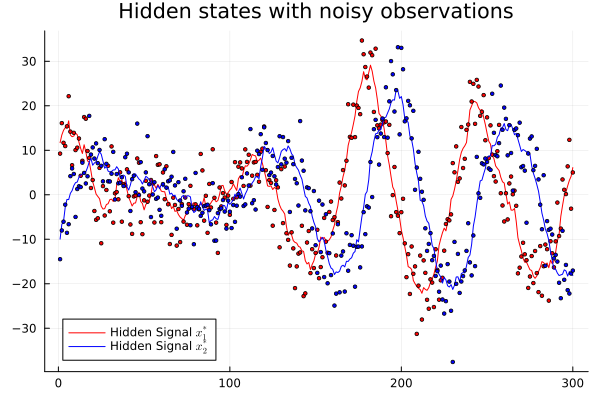

In [12]:
p = plot(title="Hidden states with noisy observations")
p = plot!(p, getindex.(_xˣ_seq, 1), label="Hidden Signal " * L"x^*_1", color=:red)
p = scatter!(p, getindex.(_y_seq, 1), label=false, markersize=2, color=:red)

p = plot!(p, getindex.(_xˣ_seq, 2), label="Hidden Signal " * L"x^*_2", color=:blue)
p = scatter!(p, getindex.(_y_seq, 2), label=false, markersize=2, color=:blue)
plot(p)

## The Generative Model

To create a model we use `GraphPPL` package and `@model` macro:

In [21]:
@model function rotate_ssm(_y_seq, _x₀, _A, _C, _Q, _R)
    _x_prior ~ MvNormalMeanCovariance(mean(_x₀), cov(_x₀))
    _xₜ₋₁ = _x_prior
    for t in 1:length(_y_seq)
        _x_seq[t] ~ MvNormalMeanCovariance(_A*_xₜ₋₁, _Q) ## `x` is a sequence of hidden states
        ##- _x[t] ~ MvNormalMeanCovariance(f(_B= _B, _xₜ₋₁= _xₜ₋₁), _Q) ## `x` is a sequence of hidden states
        _y_seq[t] ~ MvNormalMeanCovariance(_C*_x_seq[t], _R) ## `y` is a sequence of "clamped" observations
        _xₜ₋₁ = _x_seq[t]
    end
end

To run inference we also specify a prior for our first hidden state:

In [22]:
_xˣ₀ = MvNormalMeanCovariance(zeros(2), 100.0*diageye(2));

In [23]:
## For large number of observations you need to use limit_stack_depth = 100 option during model creation, e.g. 
## infer(..., options = (limit_stack_depth = 500, ))`
## We assume the Bˣ, Aˣ, Qˣ, Rˣ are known, i.e. not hidden  
result = infer(
    model=       rotate_ssm(_x₀=_xˣ₀, _A=_Aˣ, _C=_Cˣ, _Q=_Qˣ, _R=_Rˣ),
    data=        (_y_seq = _y_seq,),
    free_energy= true
);

In [24]:
result.posteriors

Dict{Symbol, Any} with 2 entries:
  :_x_seq   => MvNormalWeightedMeanPrecision{Float64, Vector{Float64}, Matrix{F…
  :_x_prior => MvNormalWeightedMeanPrecision(…

In [25]:
xmarginals  = result.posteriors[:_x_seq]
logevidence = -result.free_energy; ## given the analytical solution, free energy will be equal to the negative log evidence

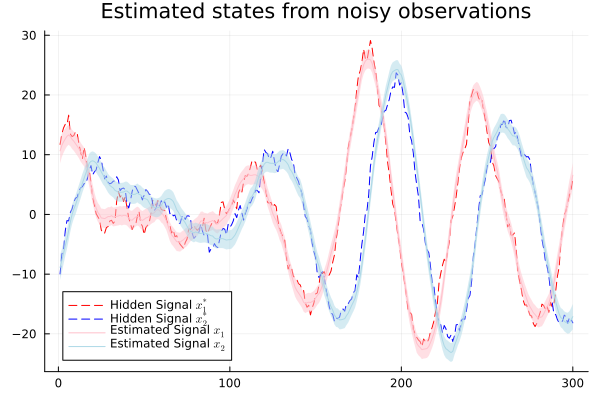

In [26]:
p = plot(title="Estimated states from noisy observations")
p = plot!(p, getindex.(_xˣ_seq, 1), label="Hidden Signal " * L"x^*_1", color=:red, linestyle=:dash)
p = plot!(p, getindex.(_xˣ_seq, 2), label="Hidden Signal " * L"x^*_2", color=:blue, linestyle=:dash)

p = plot!(p, getindex.(mean.(xmarginals), 1), ribbon=getindex.(var.(xmarginals), 1) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"x_1", color=:pink)
p = plot!(p, getindex.(mean.(xmarginals), 2), ribbon=getindex.(var.(xmarginals), 2) .|> sqrt, fillalpha=0.5, label="Estimated Signal " * L"x_2", color=:lightblue)
plot(p)

As we can see from our plot, estimated signal resembles closely to the real hidden states with small variance. We maybe also interested in the value for minus log evidence:

In [27]:
logevidence

1-element Vector{Float64}:
 -1882.2434870099432